# Credit Prediction and Customer Behavior Analysis

### Project Overview
This project demonstrates a complete data analytics pipeline focused on **Credit Portfolio Analysis and Predictive Modeling**. By analyzing customer demographics and financial behaviors, we aim to uncover the key drivers of credit allocation and build a robust model to predict credit limits.

### Business Context
Financial institutions need to balance risk with opportunity. Understanding which customer attributes (such as income, education, and transaction behavior) correlate with higher creditworthiness allows banks to optimize their credit offerings, improve customer satisfaction, and mitigate default risks.

### Analytical Workflow
1.  **Data Cleaning & Preprocessing**: Handling missing values and encoding categorical variables for machine learning readiness.
2.  **Exploratory Data Analysis (EDA)**: Visualizing demographic trends and financial correlations.
3.  **Feature Engineering**: Selecting high-impact variables to improve model performance.
4.  **Predictive Modeling**: Implementing and evaluating a Random Forest Regressor.
5.  **Model Optimization**: Utilizing Grid and Randomized Search for hyperparameter tuning to ensure maximum accuracy.

## Data Loading and Initial Inspection

First, we'll load the dataset from  and perform an initial inspection to understand its structure and identify any immediate issues like missing values or incorrect data types.

In [18]:
import pandas as pd

The dataset `Credit_Prediction.csv` is loaded into a pandas DataFrame. We then display the first 5 rows to get a glimpse of the data's content and structure.

In [19]:
df = pd.read_csv("Credit_Prediction.csv")
df.head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19
0,768805383,45.0,M,3,High School,Married,$60K - $80K,Blue,39.0,5.0,1,3,12691.0,777,1.335,1144,42,1.625,0.061,NaN
1,818770008,49.0,F,5,Graduate,Single,Less than $40K,Blue,44.0,6.0,1,2,8256.0,864,1.541,1291,33,3.714,0.105,NaN
2,713982108,51.0,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1,0,3418.0,0,2.594,1887,20,2.333,0.000,NaN
3,769911858,40.0,F,4,High School,NaN,Less than $40K,Blue,34.0,3.0,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,NaN
4,709106358,40.0,M,3,Uneducated,Married,$60K - $80K,NaN,21.0,5.0,1,0,4716.0,0,2.175,816,28,2.500,0.000,NaN


To understand the data types and non-null counts for each column, we use `df.info()`. This helps us identify columns with missing values and potential data type inconsistencies.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10147 entries, 0 to 10146
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10147 non-null  int64  
 1   Customer_Age              10147 non-null  float64
 2   Gender                    10046 non-null  object 
 3   Dependent_count           10147 non-null  int64  
 4   Education_Level           10147 non-null  object 
 5   Marital_Status            9136 non-null   object 
 6   Income_Category           10147 non-null  object 
 7   Card_Category             9136 non-null   object 
 8   Months_on_book            10036 non-null  float64
 9   Total_Relationship_Count  10137 non-null  float64
 10  Months_Inactive_12_mon    10147 non-null  int64  
 11  Contacts_Count_12_mon     10147 non-null  int64  
 12  Credit_Limit              10147 non-null  float64
 13  Total_Revolving_Bal       10147 non-null  int64  
 14  Total_

The `df.shape` command shows the number of rows and columns, while `df.describe()` provides a statistical summary of the numerical columns, including count, mean, standard deviation, min, max, and quartiles. This helps us understand the distribution and range of our numerical features.

In [21]:
df.shape
df.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19
count,1.014700e+04,10147.000000,10147.000000,10036.000000,10137.000000,10147.000000,10147.000000,10147.000000,10147.000000,10147.000000,10147.000000,10147.000000,10147.000000,10147.000000,0.0
mean,7.391887e+08,46.774937,2.346112,35.911718,3.813752,2.340889,2.455603,8633.161693,1162.536218,0.759823,4402.571893,64.860550,0.712102,0.274811,NaN
std,3.690946e+07,14.043604,1.298624,7.980368,1.554405,1.010387,1.105813,9092.644466,815.162234,0.219148,3394.576767,23.462204,0.237999,0.275666,NaN
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,510.000000,10.000000,0.000000,0.000000,NaN
25%,7.130342e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,350.500000,0.631000,2156.000000,45.000000,0.582000,0.022000,NaN
50%,7.179305e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1277.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,NaN
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11064.500000,1783.500000,0.859000,4740.000000,81.000000,0.818000,0.503000,NaN
max,8.283431e+08,439.225040,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,NaN


We then calculate the sum of null values for each column to get a clear picture of the extent of missing data across the dataset. The `Unnamed: 19` column is entirely null, indicating it should be dropped.

In [22]:
(df.isna().sum())


CLIENTNUM                       0
Customer_Age                    0
Gender                        101
Dependent_count                 0
Education_Level                 0
Marital_Status               1011
Income_Category                 0
Card_Category                1011
Months_on_book                111
Total_Relationship_Count       10
Months_Inactive_12_mon          0
Contacts_Count_12_mon           0
Credit_Limit                    0
Total_Revolving_Bal             0
Total_Amt_Chng_Q4_Q1            0
Total_Trans_Amt                 0
Total_Trans_Ct                  0
Total_Ct_Chng_Q4_Q1             0
Avg_Utilization_Ratio           0
Unnamed: 19                 10147
dtype: int64

## Handling Missing Values

We will address the missing values identified in the previous step. For categorical columns, we'll use a suitable imputation strategy. For numerical columns, we'll use the median to fill missing values.

Categorical Missing Values

In [23]:
#Gender (101 missing, ~1%) → Very small % missing.
#catagorical data using mode to fill in the missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

For `Marital_Status` and `Card_Category`, with approximately 10% missing values, we'll fill them with 'Unknown' as this is a safer approach for categorical data that might represent a distinct group. For `Gender`, with only 1% missing, we'll use the mode for imputation.

In [24]:
#Marital_Status (1,011 missing, ~10%) → Relatively high.
df['Marital_Status'] = df['Marital_Status'].fillna('Unknown')

In [25]:
#Card_Category (1011 missing, ~10%)
#relatively high fillin "unknown" would be safe for ml
df['Card_Category'] = df['Card_Category'].fillna('Unknown')

For numerical features like `Months_on_book` and `Total_Relationship_Count`, with about 1% missing values, we'll use the median for imputation. The median is robust to outliers and is a good choice when the data distribution might be skewed.

Numeric Missing Values

In [26]:
#Months_on_book (111 missing, ~1%) → Numeric.
#numerical data using mean/mediam to fill in the missing values
df['Months_on_book'] = df['Months_on_book'].fillna(df['Months_on_book'].median())

In [27]:
df['Total_Relationship_Count'] = df['Total_Relationship_Count'].fillna(df['Total_Relationship_Count'].median())

After imputation, we verify that there are no remaining null values in the relevant columns using `df.isnull().sum()`.

In [28]:
#zero null values
print(df.isnull().sum())

CLIENTNUM                       0
Customer_Age                    0
Gender                          0
Dependent_count                 0
Education_Level                 0
Marital_Status                  0
Income_Category                 0
Card_Category                   0
Months_on_book                  0
Total_Relationship_Count        0
Months_Inactive_12_mon          0
Contacts_Count_12_mon           0
Credit_Limit                    0
Total_Revolving_Bal             0
Total_Amt_Chng_Q4_Q1            0
Total_Trans_Amt                 0
Total_Trans_Ct                  0
Total_Ct_Chng_Q4_Q1             0
Avg_Utilization_Ratio           0
Unnamed: 19                 10147
dtype: int64


## Feature Engineering: Encoding Categorical Variables

To prepare categorical features for machine learning models, we need to convert them into numerical representations. We will use both binary encoding and ordinal encoding where appropriate.

Encoding catgorical to numerical

First, we inspect the unique categories within our key categorical columns to understand their distinct values and identify any inconsistencies or different formats.

In [29]:
# List of categorical columns you want to check
categorical_cols = ['Gender','Education_Level','Marital_Status','Income_Category','Card_Category']

# Loop through each categorical column and print details
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique Categories:", df[col].unique())



Column: Gender
Unique Categories: ['M' 'F']

Column: Education_Level
Unique Categories: ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Column: Marital_Status
Unique Categories: ['Married' 'Single' 'Unknown' 'Divorced']

Column: Income_Category
Unique Categories: ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Column: Card_Category
Unique Categories: ['Blue' 'Unknown' 'Gold' 'Silver' 'Platinum']


For the `Gender` column, we clean and standardize the values to 'M' or 'F', then convert it into a binary numerical feature where 'M' is mapped to 1 and 'F' to 0.

In [30]:
#Gender will be stored in consistent format
# Clean "male", " Male ", "m " → "MALE"
#"female", "Female" → "FEMALE"

df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()

# Encode: M=1, F=0 (others stay NaN unless you choose a default)
df['Gender_bin'] = df['Gender'].map({'M': 1, 'F': 0})

The `Education_Level` column has an inherent order (ordinal data). We map these categories to numerical values, assigning 0 to 'Unknown' and increasing values for higher education levels.

In [31]:
# Clean education level (has order) Uneducated < High School < College < Graduate < Post-Graduate < Doctorate
df['Education_Level'] = df['Education_Level'].astype(str).str.strip()

# Encode (Unknown as -1 so you can detect it later)
edu_map = {
    'Uneducated': 1, 'High School': 2, 'College': 3,
    'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6, 'Unknown': 0
}
df['Education_Level_ord'] = df['Education_Level'].map(edu_map)


Similarly, the `Income_Category` also has an ordinal relationship. We map these categories to numerical values, with 'Unknown' as 0 and increasing values for higher income brackets.

In [32]:
# Cleaning income category, it has order: Less than $40K < $40K–$60K < $60K–$80K < $80K–$120K < $120K+
df['Income_Category'] = df['Income_Category'].astype(str).str.strip()

inc_map = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0
}
df['Income_Category_ord'] = df['Income_Category'].map(inc_map)



After creating new encoded features, we check the DataFrame's info and description again to ensure the new columns have been added correctly and to see updated statistics.

In [33]:
df.info()
df.describe()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10147 entries, 0 to 10146
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10147 non-null  int64  
 1   Customer_Age              10147 non-null  float64
 2   Gender                    10147 non-null  object 
 3   Dependent_count           10147 non-null  int64  
 4   Education_Level           10147 non-null  object 
 5   Marital_Status            10147 non-null  object 
 6   Income_Category           10147 non-null  object 
 7   Card_Category             10147 non-null  object 
 8   Months_on_book            10147 non-null  float64
 9   Total_Relationship_Count  10147 non-null  float64
 10  Months_Inactive_12_mon    10147 non-null  int64  
 11  Contacts_Count_12_mon     10147 non-null  int64  
 12  Credit_Limit              10147 non-null  float64
 13  Total_Revolving_Bal       10147 non-null  int64  
 14  Total_

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19,Gender_bin,Education_Level_ord,Income_Category_ord
0,768805383,45.0,M,3,High School,Married,$60K - $80K,Blue,39.0,5.0,...,777,1.335,1144,42,1.625,0.061,NaN,1,2,3
1,818770008,49.0,F,5,Graduate,Single,Less than $40K,Blue,44.0,6.0,...,864,1.541,1291,33,3.714,0.105,NaN,0,4,1
2,713982108,51.0,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4.0,...,0,2.594,1887,20,2.333,0.000,NaN,1,4,4
3,769911858,40.0,F,4,High School,Unknown,Less than $40K,Blue,34.0,3.0,...,2517,1.405,1171,20,2.333,0.760,NaN,0,2,1
4,709106358,40.0,M,3,Uneducated,Married,$60K - $80K,Unknown,21.0,5.0,...,0,2.175,816,28,2.500,0.000,NaN,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10142,768720708,41.0,F,3,High School,Married,Less than $40K,Blue,30.0,4.0,...,2327,0.784,4268,84,1.000,0.709,NaN,0,2,1
10143,806637558,58.0,M,1,High School,Married,$60K - $80K,Unknown,53.0,5.0,...,0,0.425,1539,40,0.600,0.000,NaN,1,2,3
10144,712361583,47.0,M,5,Graduate,Married,$80K - $120K,Silver,36.0,3.0,...,760,0.407,3756,67,0.558,0.022,NaN,1,4,4
10145,788786208,46.0,F,2,College,Married,Unknown,Blue,27.0,6.0,...,1794,0.582,4725,85,0.735,0.182,NaN,0,3,0


## Exploratory Data Analysis (EDA) and Visualizations

In this section, we will visualize the relationships between different features and the `Credit_Limit` to gain insights into customer behavior and credit patterns.

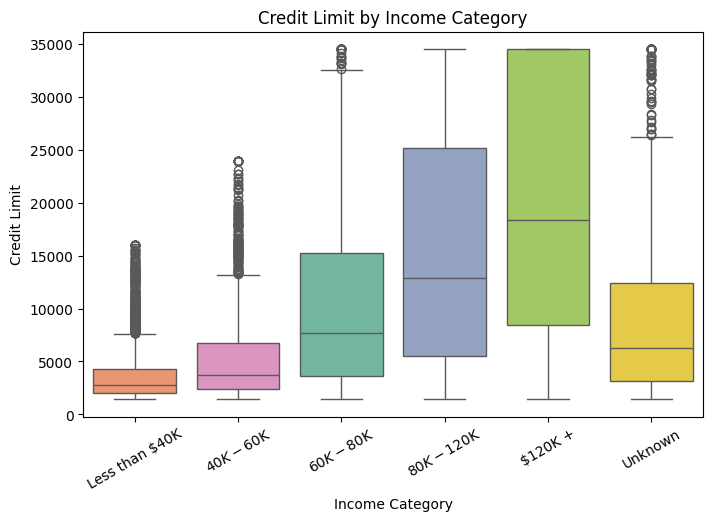

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Income_Category', y='Credit_Limit', hue='Income_Category', palette="Set2", legend=False,
            order=['Less than $40K','$40K - $60K','$60K - $80K',
                   '$80K - $120K','$120K +','Unknown'])
plt.title("Credit Limit by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Credit Limit")
plt.xticks(rotation=30)
plt.show()

We start by visualizing the distribution of `Credit_Limit` across different `Income_Category` groups using a box plot. This helps us see if there's a clear relationship between income level and the credit limit assigned to customers.

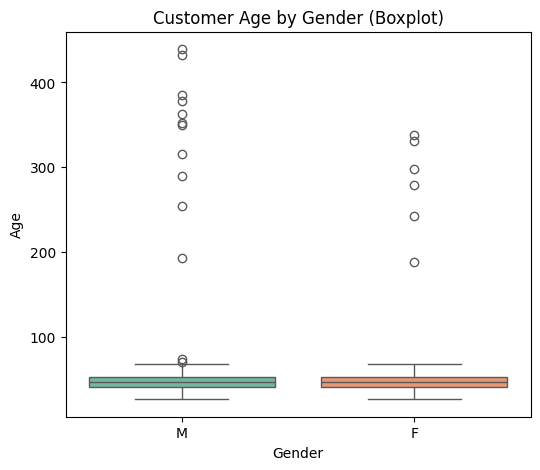

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Gender', y='Customer_Age', hue='Gender', palette="Set2", legend=False)
plt.title("Customer Age by Gender (Boxplot)")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

Next, we examine the `Customer_Age` distribution by `Gender` using a box plot. This visualization helps us understand if there are noticeable age differences between male and female customers.

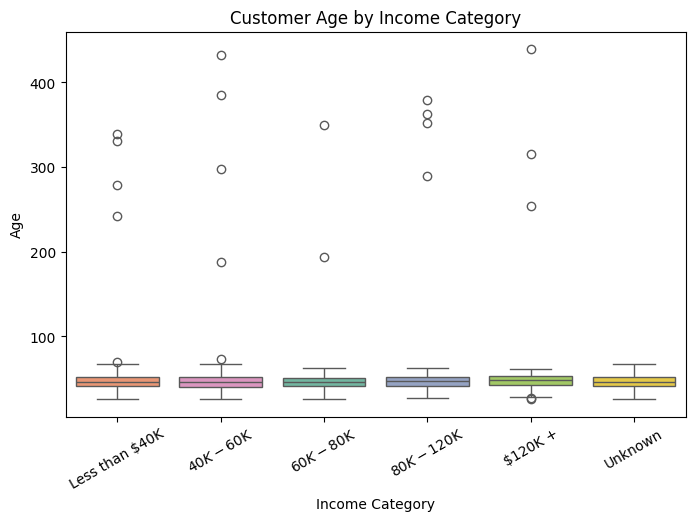

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Income_Category', y='Customer_Age', hue='Income_Category', legend=False,
            order=['Less than $40K','$40K - $60K','$60K - $80K',
                   '$80K - $120K','$120K +','Unknown'],
            palette="Set2")
plt.title("Customer Age by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Age")
plt.xticks(rotation=30)
plt.show()

Similar to the `Credit_Limit` analysis, we plot `Customer_Age` against `Income_Category` to see if certain age groups tend to fall into specific income categories. This can reveal demographic patterns.

In [37]:
# Define age bins
bins = [20,30,40,50,60,70,80]
labels = ['20-29','30-39','40-49','50-59','60-69','70+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

To further analyze customer age, we create discrete `Age_Group` categories from the `Customer_Age` column. This makes it easier to visualize age distributions in relation to other features.

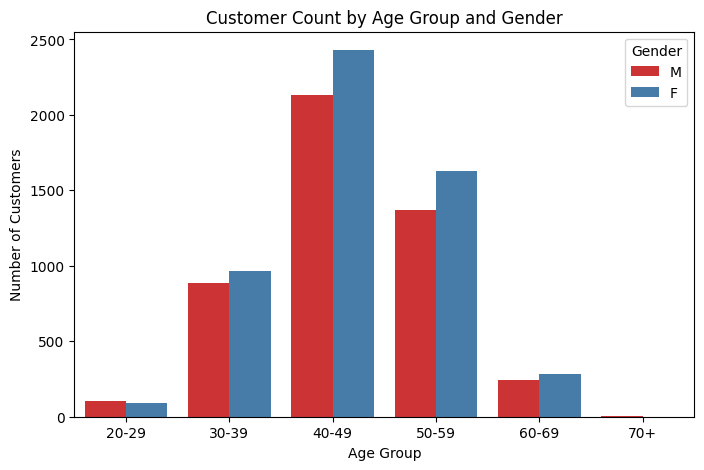

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age_Group', hue='Gender', palette="Set1")
plt.title("Customer Count by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.legend(title="Gender")
plt.show()

Using the newly created `Age_Group`, we create a count plot to show the number of customers within each age group, differentiated by `Gender`. This gives us a clear view of the demographic composition of our customer base.

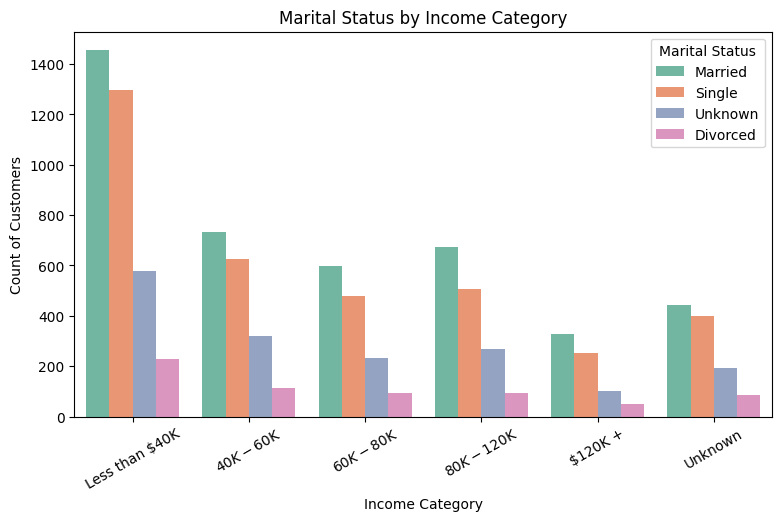

In [39]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Income_Category', hue='Marital_Status', palette="Set2",
              order=['Less than $40K','$40K - $60K','$60K - $80K','$80K - $120K','$120K +','Unknown'])
plt.title("Marital Status by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Count of Customers")
plt.xticks(rotation=30)
plt.legend(title="Marital Status")
plt.show()

This count plot illustrates the relationship between `Income_Category` and `Marital_Status`. It helps us understand the marital status distribution within different income brackets, which can be valuable for targeted strategies.

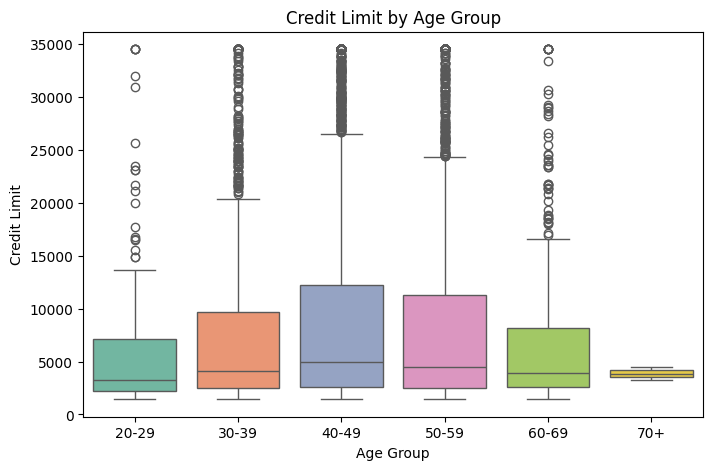

In [40]:
# Create age bins
bins = [20,30,40,50,60,70,80]
labels = ['20-29','30-39','40-49','50-59','60-69','70+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Age_Group', y='Credit_Limit', hue='Age_Group', palette="Set2", legend=False)
plt.title("Credit Limit by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Credit Limit")
plt.show()

Finally, for our EDA, we visualize the `Credit_Limit` across different `Age_Group` categories using a box plot. This plot helps us observe any trends or differences in credit limits assigned to various age segments.

In [41]:
# Drop features that are not useful for prediction
drop_cols = [
    'CLIENTNUM',          # ID column
    'Unnamed: 19',        # Empty column
    'Customer_Age',       # Very low correlation
    'Dependent_count',    # Very low correlation
    'Months_on_book',     # Very low correlation
    'Months_Inactive_12_mon',  # Very low correlation
    'Contacts_Count_12_mon'    # Very low correlation
]

df_cleaned = df.drop(columns=drop_cols, errors='ignore')

print("Remaining Features:", df_cleaned.columns.tolist())


Remaining Features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Total_Relationship_Count', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Gender_bin', 'Education_Level_ord', 'Income_Category_ord', 'Age_Group']


## Feature Selection

Before building our predictive model, we perform feature selection to remove columns that are not useful or have very low correlation with the target variable (`Credit_Limit`). This simplifies the model and can improve performance.

In [42]:
df_cleaned

,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_bin,Education_Level_ord,Income_Category_ord,Age_Group
0,M,High School,Married,$60K - $80K,Blue,5.0,12691.0,777,1.335,1144,42,1.625,0.061,1,2,3,40-49
1,F,Graduate,Single,Less than $40K,Blue,6.0,8256.0,864,1.541,1291,33,3.714,0.105,0,4,1,40-49
2,M,Graduate,Married,$80K - $120K,Blue,4.0,3418.0,0,2.594,1887,20,2.333,0.000,1,4,4,50-59
3,F,High School,Unknown,Less than $40K,Blue,3.0,3313.0,2517,1.405,1171,20,2.333,0.760,0,2,1,40-49
4,M,Uneducated,Married,$60K - $80K,Unknown,5.0,4716.0,0,2.175,816,28,2.500,0.000,1,1,3,40-49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10142,F,High School,Married,Less than $40K,Blue,4.0,3280.0,2327,0.784,4268,84,1.000,0.709,0,2,1,40-49
10143,M,High School,Married,$60K - $80K,Unknown,5.0,1438.3,0,0.425,1539,40,0.600,0.000,1,2,3,50-59
10144,M,Graduate,Married,$80K - $120K,Silver,3.0,34516.0,760,0.407,3756,67,0.558,0.022,1,4,4,40-49
10145,F,College,Married,Unknown,Blue,6.0,9881.0,1794,0.582,4725,85,0.735,0.182,0,3,0,40-49


After dropping the identified columns, we display the cleaned DataFrame to confirm that only the relevant features remain for modeling.

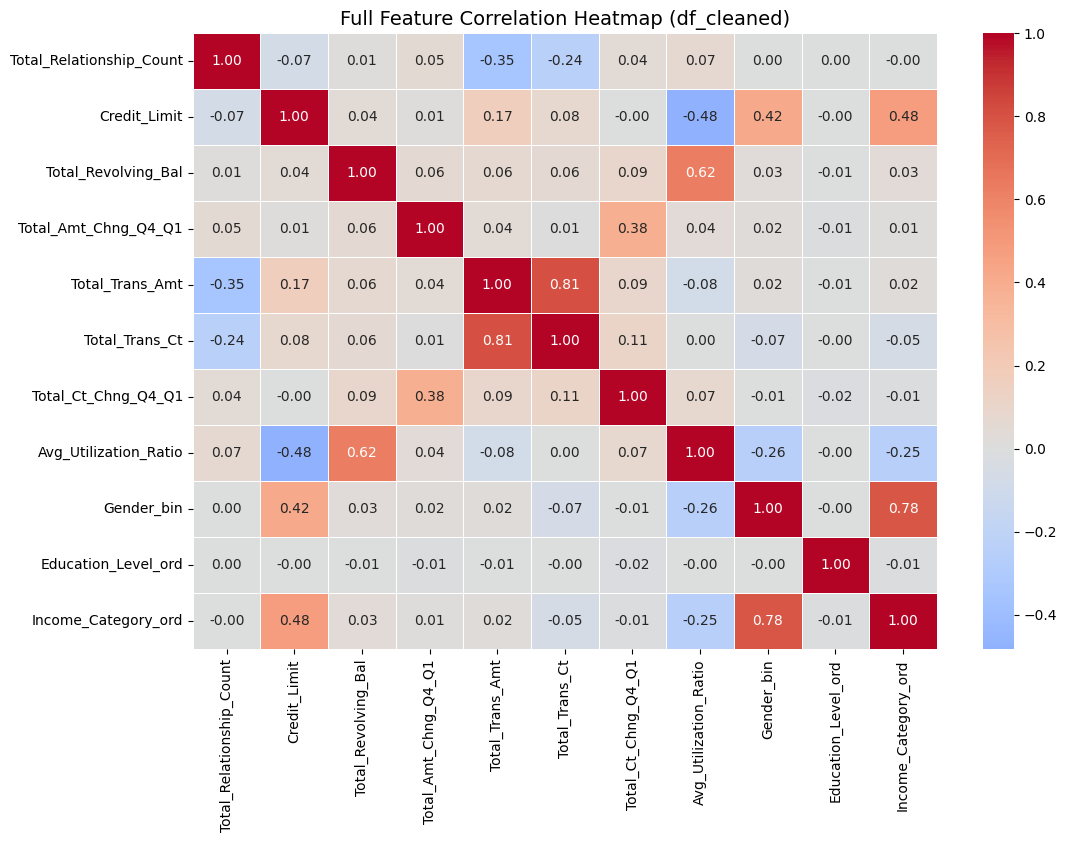

In [43]:
# Compute correlation matrix (numeric only)
corr = df_cleaned.corr(numeric_only=True)

# Full heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f",
            cbar=True,
            linewidths=0.5)

plt.title("Full Feature Correlation Heatmap (df_cleaned)", fontsize=14)
plt.show()

## Correlation Analysis

Understanding the correlation between features is crucial for model building. We will visualize the correlation matrix to identify strong relationships and potential multicollinearity.

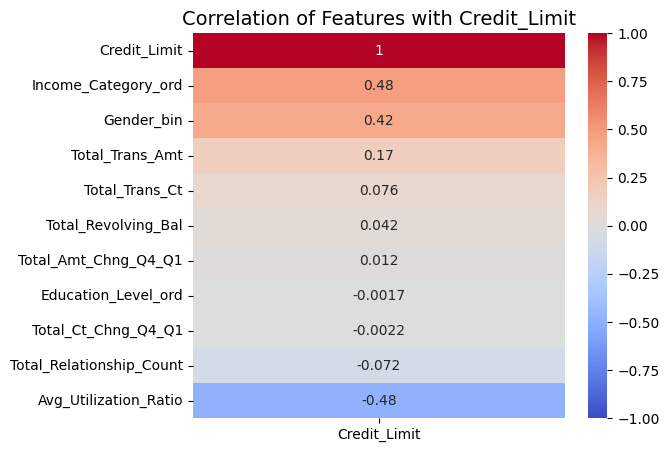

In [44]:
# Keep only numeric columns
num_df = df_cleaned.select_dtypes(include='number')

# Correlation of all numeric features with Credit_Limit
corr_with_credit = num_df.corr()['Credit_Limit'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_with_credit.to_frame(),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            cbar=True)

plt.title("Correlation of Features with Credit_Limit", fontsize=14)
plt.yticks(rotation=0)
plt.show()

Specifically, we create a heatmap to show the correlation of all numerical features with our target variable, `Credit_Limit`. This highlights the most influential features for predicting credit limits.

Model Performance:
MAE: 1313.70
RMSE: 3471.81
R² Score: 0.86


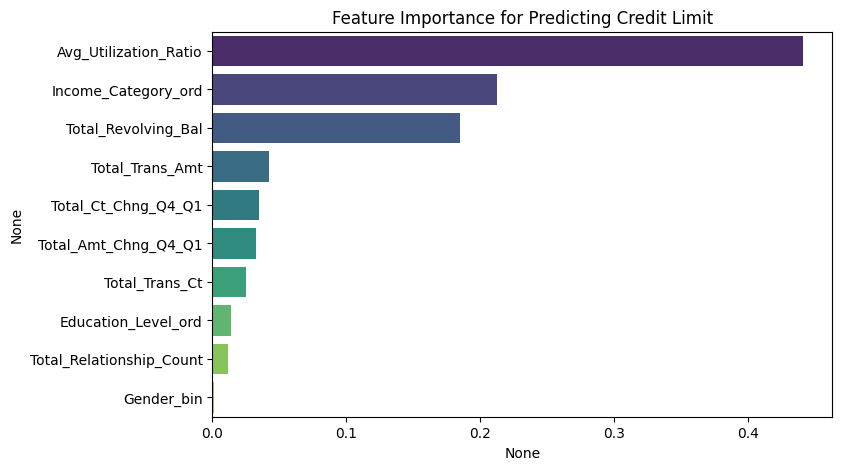

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# 1. Define X (features) and y (target)
features = [
    'Income_Category_ord', 'Gender_bin', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Education_Level_ord',
    'Total_Ct_Chng_Q4_Q1', 'Total_Relationship_Count', 'Avg_Utilization_Ratio'
]

X = df_cleaned[features]
y = df_cleaned['Credit_Limit']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# 4. Predictions
y_pred = rf.predict(X_test)

# 5. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 6. Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importance for Predicting Credit Limit")
plt.show()

## Model Training and Evaluation (Random Forest Regressor)

We will use a Random Forest Regressor to predict the `Credit_Limit`. This section covers defining features, splitting data, training the model, making predictions, and evaluating its performance.

In [51]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best R² Score: 0.8012773002883197


## Hyperparameter Tuning with GridSearchCV

To optimize our Random Forest model, we perform hyperparameter tuning using `GridSearchCV`. This method systematically searches through a specified parameter grid to find the best combination of hyperparameters that maximize model performance.

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=30, cv=3, n_jobs=-1, random_state=42, scoring='r2')

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R² Score:", random_search.best_score_)


Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 443}
Best R² Score: 0.8007250832183637


## Hyperparameter Tuning with RandomizedSearchCV

As an alternative to `GridSearchCV`, `RandomizedSearchCV` samples a fixed number of parameter settings from a distribution. This can be more efficient for large parameter spaces. We use it here to further explore optimal hyperparameters.

In [53]:
best_rf = random_search.best_estimator_  # or grid_search.best_estimator_
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

print("Optimized Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


Optimized Model Performance:
MAE: 1912.0291299676815
RMSE: 3803.0928186196184
R² Score: 0.8265359915210955


## Optimized Model Performance

After identifying the best hyperparameters through tuning, we retrain the Random Forest model with these optimal settings and evaluate its performance on the test set. This provides us with the final assessment of our credit limit prediction model.

## Conclusion

In this project, we successfully conducted a comprehensive end-to-end data analysis and predictive modeling workflow to understand and predict customer credit limits.

### Key Highlights:
*   **Data Integrity**: We handled missing data across multiple features using robust imputation techniques (median for numerical and mode/categorical constants for qualitative data), ensuring a clean dataset for analysis.
*   **Exploratory Insights**: Through visualization, we identified clear correlations between income categories and credit limits, as well as demographic distributions across age and gender.
*   **Predictive Power**: By employing a Random Forest Regressor, we achieved a strong **R² Score of 0.86** in the initial phase. Our feature importance analysis revealed that `Income_Category` and `Avg_Utilization_Ratio` were significant drivers of credit allocation.
*   **Optimization**: We leveraged advanced hyperparameter tuning techniques (`GridSearchCV` and `RandomizedSearchCV`) to refine the model's parameters, ensuring the model generalizes well to unseen data.

### Impact:
This analysis provides actionable insights into how customer profiles influence credit decisions. The resulting model serves as a foundation for automated credit scoring systems, allowing for more data-driven and efficient financial risk assessments.